<a href="https://colab.research.google.com/github/buikhoinguyen9122007-crypto/ai/blob/B%C3%B9i-Kh%C3%B4i-Nguy%C3%AAn---31251026263/Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
#23.1
import folium
from geopy.geocoders import Nominatim
geo = Nominatim(user_agent="map")
ueh = geo.geocode("Đại học Kinh tế, TP.HCM")
pos_ueh = (ueh.latitude, ueh.longitude)
ban_do = folium.Map(location=pos_ueh)
folium.Marker(pos_ueh, popup="UEH", icon=folium.Icon(color="red")).add_to(ban_do)
places = ["Bệnh viện Chợ Rẫy","Chợ Tân Định","Bưu điện Trung tâm Sài Gòn","Nhà thờ Đức Bà"]
for place in places:
    kq = geo.geocode(place + ", TP.HCM")
    if kq:
        folium.Marker((kq.latitude, kq.longitude), popup=place, icon=folium.Icon(color="blue")).add_to(ban_do)
display(ban_do)

In [8]:
#23.2
import folium
from geopy.geocoders import Nominatim
geo=Nominatim(user_agent="map")
ueh=geo.geocode("Đại học Kinh tế, TP.HCM")
goc=(ueh.latitude,ueh.longitude)
ban_do=folium.Map(location=goc)
folium.Marker(goc,icon=folium.Icon(color="red")).add_to(ban_do)
for p in ["Bitexco Financial Tower","Bến xe Miền Đông","Công viên Gia Định"]:
    kq=geo.geocode(p+", TP.HCM")
    if kq:
        d=(kq.latitude,kq.longitude)
        folium.Marker(d).add_to(ban_do)
        folium.PolyLine([goc,d]).add_to(ban_do)
display(ban_do)

In [9]:
#23.3
import folium
from folium.plugins import HeatMap
ban_do=folium.Map(location=[10.7325,106.7145])
data=[[10.7325,106.7145,0.9],[10.7310,106.7150,0.8],[10.7330,106.7130,0.9],[10.7350,106.7100,0.7],[10.7300,106.7200,0.6],[10.7400,106.7050,0.5],[10.7250,106.7250,0.4],[10.7450,106.7000,0.3],[10.7200,106.7300,0.2]]
HeatMap(data).add_to(ban_do)
display(ban_do)

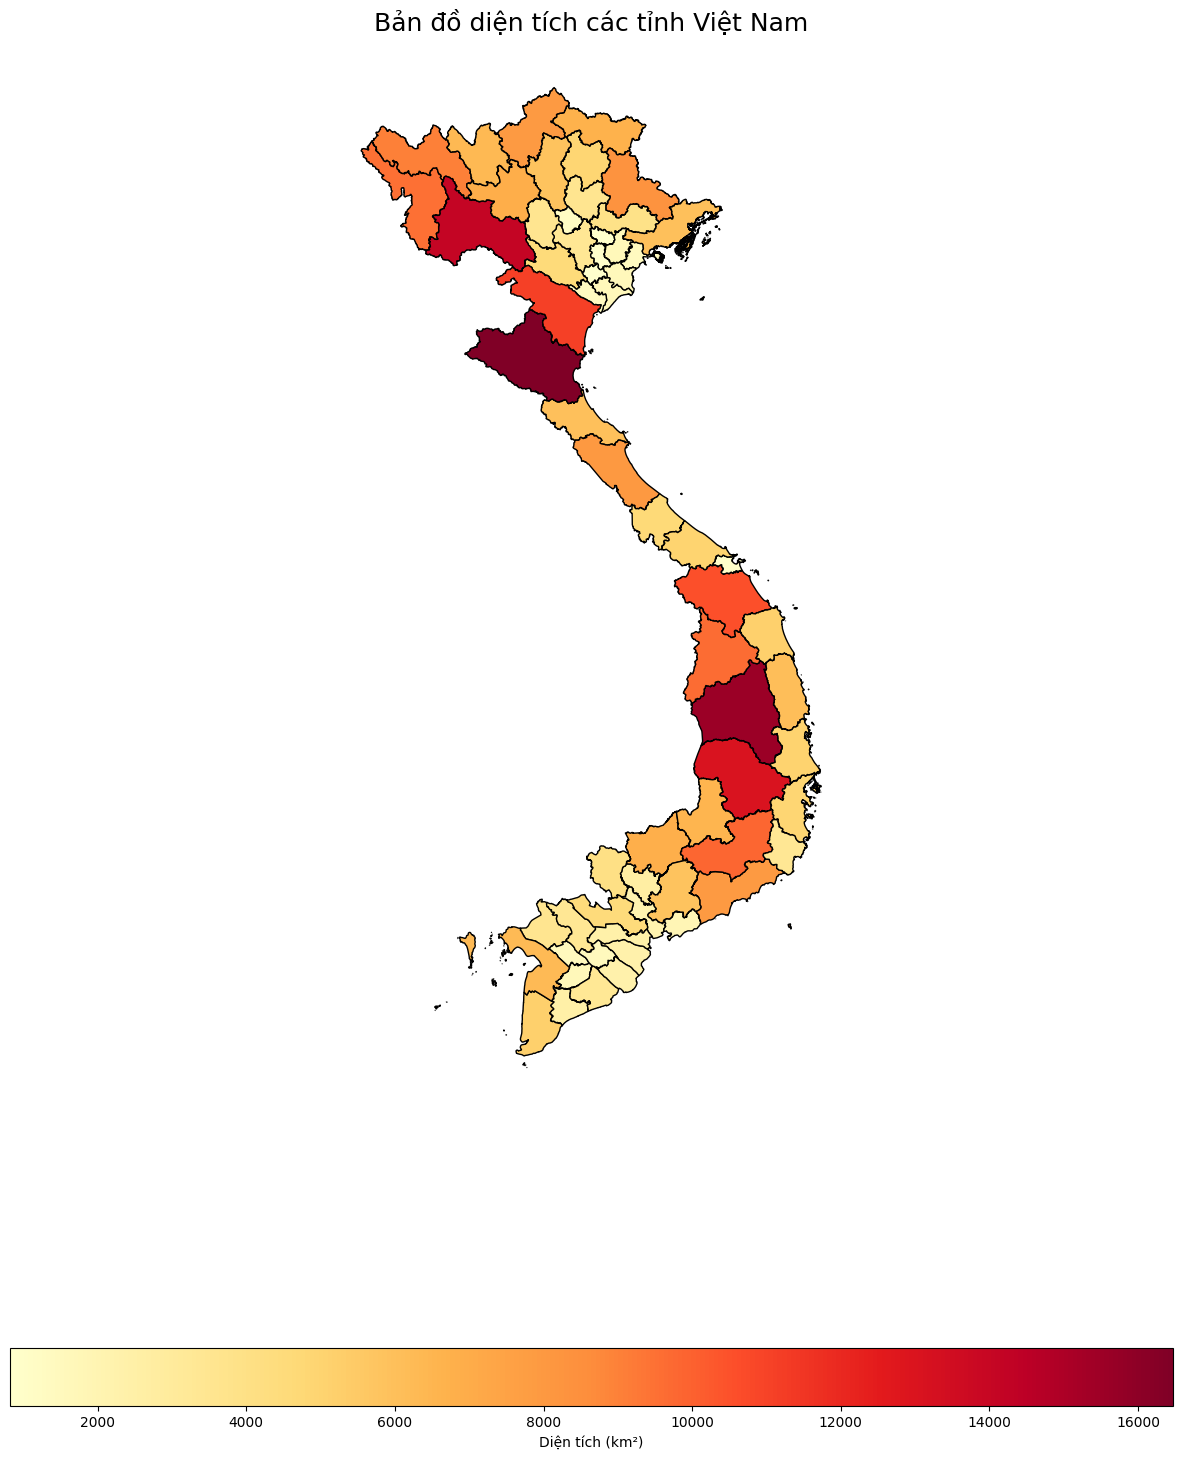

In [33]:
#23.4
import geopandas as gpd
import matplotlib.pyplot as plt
vnm=gpd.read_file("/content/gadm41_VNM_1.json")
vnm=vnm.to_crs(epsg=3405)
vnm["area_km2"]=vnm["geometry"].area/10**6
fig,ax=plt.subplots(figsize=(15,20))
vnm.plot(column="area_km2",ax=ax,cmap="YlOrRd",edgecolor="black",legend=True,legend_kwds={"label":"Diện tích (km²)","orientation":"horizontal"})
plt.title("Bản đồ diện tích các tỉnh Việt Nam",fontsize=18)
cmap='Blues'
ax.set_axis_off()
plt.show()

In [12]:
#23.5
import folium
from geopy.geocoders import Nominatim
geo=Nominatim(user_agent="map")
ueh=geo.geocode("Đại học Kinh tế, TP.HCM")
goc=[ueh.latitude,ueh.longitude]
ban_do=folium.Map(location=goc)
folium.Marker(goc,icon=folium.Icon(color="red")).add_to(ban_do)
folium.Circle(goc,radius=500,color="green",fill=True,tooltip="Khu vực gần (0.5km)").add_to(ban_do)
folium.Circle(goc,radius=2000,color="blue",fill=False,tooltip="Khu vực trung bình (2km)").add_to(ban_do)
folium.Circle(goc,radius=8000,color="orange",fill=False,tooltip="Khu vực xa (8km)").add_to(ban_do)
display(ban_do)

Nhà thờ Đức Bà
Số lượng nút giao: 387
Chiều dài đường trung bình: 89.71 mét


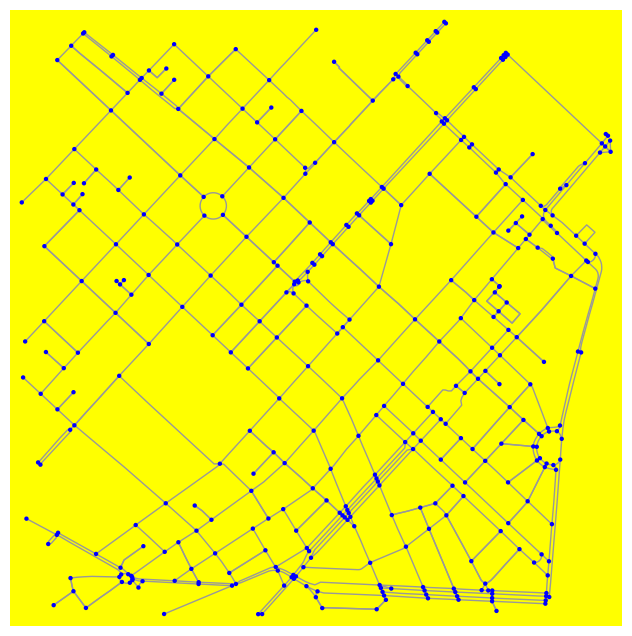

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [25]:
#23.6
import osmnx as ox

place="Nhà thờ Đức Bà, Ho Chi Minh City, Vietnam"
g=ox.graph_from_address(place,dist=1000,network_type="drive")
s=ox.basic_stats(g)
print("Nhà thờ Đức Bà")
print(f"Số nút giao: {s['n']}")
print(f"Chiều dài đường trung bình: {s['edge_length_avg']:.2f} mét")
ox.plot_graph(g,node_size=10,node_color="blue",bgcolor="yellow")

In [26]:
#23.7
import osmnx as ox
import networkx as nx
import folium
diem_bat_dau=ox.geocode("UEH University, Ho Chi Minh City, Vietnam")
diem_ket_thuc=ox.geocode("Saigon Zoo and Botanical Gardens, Ho Chi Minh City, Vietnam")
do_thi=ox.graph_from_point(diem_bat_dau,dist=1200,network_type="drive")
nut_dau=ox.distance.nearest_nodes(do_thi,diem_bat_dau[1],diem_bat_dau[0])
nut_cuoi=ox.distance.nearest_nodes(do_thi,diem_ket_thuc[1],diem_ket_thuc[0])
duong_1=nx.shortest_path(do_thi,nut_dau,nut_cuoi,weight="length")
def ham_uoc_luong(a,b): return ox.distance.euclidean(do_thi.nodes[a]["y"],do_thi.nodes[a]["x"],do_thi.nodes[b]["y"],do_thi.nodes[b]["x"])
duong_2=nx.astar_path(do_thi,nut_dau,nut_cuoi,heuristic=ham_uoc_luong,weight="length")
ban_do=folium.Map(location=diem_bat_dau)
toa_do_1=[(do_thi.nodes[i]["y"],do_thi.nodes[i]["x"]) for i in duong_1]
toa_do_2=[(do_thi.nodes[i]["y"],do_thi.nodes[i]["x"]) for i in duong_2]
folium.PolyLine(toa_do_1,color="orange",weight=6).add_to(ban_do)
folium.PolyLine(toa_do_2,color="black",weight=2).add_to(ban_do)
display(ban_do)

In [29]:
#23.13
import folium
import osmnx as ox
diem_1=ox.geocode("Aeon Mall Tan Phu, Ho Chi Minh City, Vietnam")
diem_2=ox.geocode("Dam Sen Park, Ho Chi Minh City, Vietnam")
v1=ox.geocode("Tan Phu District, Ho Chi Minh City, Vietnam")
v2=ox.geocode("Phu Tho Hoa Ward, Ho Chi Minh City, Vietnam")
v3=ox.geocode("Hoa Binh Street, Ho Chi Minh City, Vietnam")
v4=ox.geocode("Lu Gia Street, Ho Chi Minh City, Vietnam")
t1=ox.geocode("Giac Lam Pagoda, Ho Chi Minh City, Vietnam")
t2=ox.geocode("Thong Nhat Stadium, Ho Chi Minh City, Vietnam")
t3=ox.geocode("Dam Sen Park, Ho Chi Minh City, Vietnam")
ban_do=folium.Map(location=diem_2)
lop_a=folium.FeatureGroup(name="Điểm giao")
folium.Marker(diem_1).add_to(lop_a)
folium.Marker(diem_2).add_to(lop_a)
lop_b=folium.FeatureGroup(name="Vùng phục vụ")
folium.Polygon(locations=[v1,v2,v3,v4],color="purple",fill=True).add_to(lop_b)
lop_c=folium.FeatureGroup(name="Tuyến đường")
folium.PolyLine(locations=[t1,t2,t3],color="orange",weight=4).add_to(lop_c)
lop_a.add_to(ban_do)
lop_b.add_to(ban_do)
lop_c.add_to(ban_do)
folium.LayerControl().add_to(ban_do)
display(ban_do)